In [4]:
%pip install pandas
%pip install matplotlib
%pip install seaborn

In [16]:
import pandas as pd

df = pd.read_csv("/Users/smabbasht/Unimib/Machine Learning/datasets/adult.csv")

df = df[df["age"] == '?']
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income


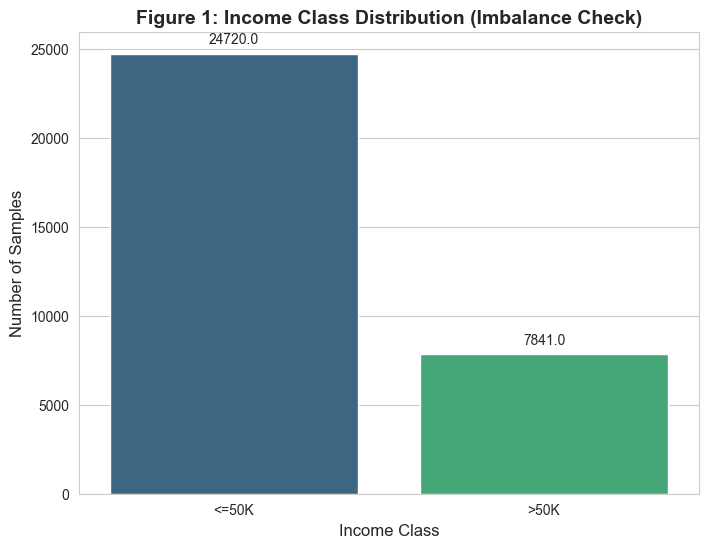

✅ Figure 1 saved as 'fig1_class_distribution.png'


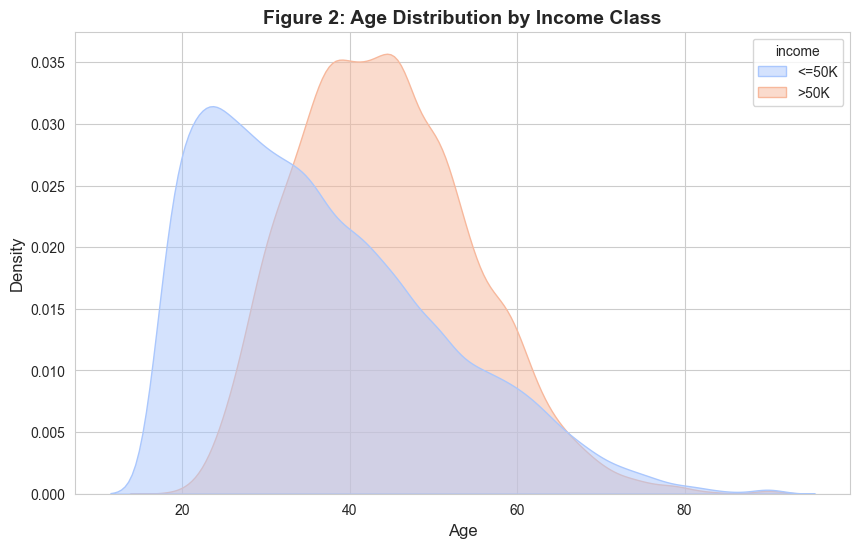

✅ Figure 2 saved as 'fig2_age_by_income.png'


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
# Assuming standard column names. Adjust if your CSV has no headers.
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 
           'hours-per-week', 'native-country', 'income']

try:
    df = pd.read_csv('/Users/smabbasht/Unimib/Machine Learning/datasets/adult.csv', names=columns, skipinitialspace=True, header=0)
    
    # Ensure age is numeric
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    df = df.dropna(subset=['age'])
except FileNotFoundError:
    print("Error: 'adult.csv' not found. Please upload the file.")
    df = None

if df is not None:
    # Set the aesthetic style
    sns.set_style("whitegrid")
    
    # --- FIGURE 1: Income Class Distribution ---
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x='income', data=df, hue='income', palette='viridis', legend=False)
    
    # Add counts on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
    
    plt.title('Figure 1: Income Class Distribution (Imbalance Check)', fontsize=14, fontweight='bold')
    plt.xlabel('Income Class', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.savefig('fig1_class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Figure 1 saved as 'fig1_class_distribution.png'")

    # --- FIGURE 2: Feature Distribution (Age vs Income) ---
    # We use Age because it shows a very clear, interpretable shift
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='age', hue='income', fill=True, common_norm=False, palette='coolwarm', alpha=0.5)
    
    plt.title('Figure 2: Age Distribution by Income Class', fontsize=14, fontweight='bold')
    plt.xlabel('Age', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.savefig('fig2_age_by_income.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Figure 2 saved as 'fig2_age_by_income.png'")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Data & Fix Column Names ---
try:
    # Read CSV
    df = pd.read_csv('/Users/smabbasht/Unimib/Machine Learning/datasets/adult.csv', skipinitialspace=True, header=0)
    
    # CRITICAL FIX: Standardize column names
    # 1. Strip whitespace
    # 2. Lowercase everything
    # 3. Replace dots (.) with hyphens (-) to match standard names
    df.columns = df.columns.str.strip().str.lower().str.replace('.', '-', regex=False)
    
    # Print columns to verify (Debug step)
    print("✅ Columns detected:", df.columns.tolist())

    # Clean numeric columns (force them to numbers)
    # Note: We now use the hyphenated names because we fixed them above
    numeric_cols = ['capital-gain', 'education-num', 'hours-per-week']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            print(f"⚠️ Warning: Column '{col}' not found. Check the printed column list above.")
        
    # Drop rows with NaNs in these columns to prevent plotting crashes
    # We also check if 'income' exists
    cols_to_check = [c for c in numeric_cols if c in df.columns] + ['income']
    df = df.dropna(subset=cols_to_check)
    
    print("✅ Data Cleaned Successfully.")

    # --- 2. Set Style ---
    sns.set_style("whitegrid")

    # --- PLOT 3: Capital Gain Distribution (Boxplot) ---
    if 'capital-gain' in df.columns:
        plt.figure(figsize=(10, 6))
        ax = sns.boxplot(x='income', y='capital-gain', data=df, palette='viridis')
        ax.set_yscale('symlog') # Log scale handles the huge outliers
        
        plt.title('Figure 3: Capital Gain Distribution by Income (Log Scale)', fontsize=14, fontweight='bold')
        plt.xlabel('Income Class', fontsize=12)
        plt.ylabel('Capital Gain (Log Scale)', fontsize=12)
        plt.tight_layout()
        plt.savefig('fig3_capital_gain.png', dpi=300)
        print("✅ Figure 3 saved as 'fig3_capital_gain.png'")

    # --- PLOT 4: Education-Num vs Income (Boxplot) ---
    if 'education-num' in df.columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(x='income', y='education-num', data=df, palette='coolwarm')
        
        plt.title('Figure 4: Education Level (Years) by Income Class', fontsize=14, fontweight='bold')
        plt.xlabel('Income Class', fontsize=12)
        plt.ylabel('Years of Education', fontsize=12)
        plt.yticks(range(0, 18, 2))
        plt.tight_layout()
        plt.savefig('fig4_education_num.png', dpi=300)
        print("✅ Figure 4 saved as 'fig4_education_num.png'")

    # --- PLOT 5: Hours per Week Distribution (KDE Plot) ---
    if 'hours-per-week' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=df, x='hours-per-week', hue='income', fill=True, 
                    common_norm=False, palette='mako', alpha=0.5)
        
        plt.title('Figure 5: Hours Worked Per Week by Income Class', fontsize=14, fontweight='bold')
        plt.xlabel('Hours per Week', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.xlim(0, 80)
        plt.tight_layout()
        plt.savefig('fig5_hours_per_week.png', dpi=300)
        print("✅ Figure 5 saved as 'fig5_hours_per_week.png'")
    
    plt.show()

except FileNotFoundError:
    print("❌ Error: 'adult.csv' not found. Please upload the file.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

❌ An unexpected error occurred: 'capital.gain'
